# LSTM + Transformer v6 — full sequence-track notebook

General-purpose privilege-escalation **sequence** model. v5 (bert-jan specialist) is a separate notebook and is not modified here.

| Item | Value |
|---|---|
| Model | BiLSTM + 1-layer Transformer + tabular skip + secrets head (same class as v5) |
| Data | `data/lstm/cloudtrail_temporal_final.csv` (dedupe `log_id`) |
| Train unit | one history per event (last 10 min, **T=32**, right-pad) |
| Labels | CSV `label` only (no campaign relabel) |
| Split | **user-disjoint** GroupShuffleSplit ~70/15/15 — no locked attacker |
| Fusion | `P_seq = max(P_event)` in each 10-min / stride-2 window |
| Checkpoint | `artifacts/lstm_transformer_v6/temporal_lstm_transformer_v6.pt` |

Train from the shell: `python train_lstm_transformer_v6.py`  
Or set `RUN_TRAIN = True` below (overwrites v6 artifacts only).


## 1. Setup


In [1]:
# Paths, plotting style, import v6 trainer (v5 file is only used for the shared model class).

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
)

import train_lstm_transformer_v6 as t6

RUN_TRAIN = False

ROOT = Path(".").resolve()
OUT = t6.OUT_DIR
PLOT_DIR = OUT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
V5_CKPT = ROOT / "artifacts" / "lstm_transformer" / "temporal_lstm_transformer.pt"
V5_VOCAB = ROOT / "data" / "lstm" / "event_name_vocab.json"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 140,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titlesize": 13,
        "figure.facecolor": "white",
    }
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t6.set_seed()
print("device:", device)
print("csv:", t6.CSV_PATH)
print("v6 artifacts:", OUT)
print("v5 ckpt still there:", V5_CKPT.exists(), "| v5 vocab still there:", V5_VOCAB.exists())
print("RUN_TRAIN:", RUN_TRAIN)


device: cpu
csv: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\data\lstm\cloudtrail_temporal_final.csv
v6 artifacts: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6
v5 ckpt still there: True | v5 vocab still there: True
RUN_TRAIN: False


## 2. Data

`cloudtrail_temporal_final.csv` uses the same 40-column temporal schema. Twin rows sharing `log_id` are dropped (keep last). Usernames are raw CloudTrail principals — no `inv:` / `fe:` / `syn:` prefixes.


In [2]:
df, feature_cols, vocab_size = t6.load_and_validate(t6.CSV_PATH)
vocab = json.loads(t6.VOCAB_PATH.read_text(encoding="utf-8")) if t6.VOCAB_PATH.exists() else t6.write_vocab_v6(vocab_size)
pe_ids, sec_ids = t6.maybe_pe_ids(vocab)
if pe_ids:
    df = t6.attach_pe_context(df, pe_ids)
    feature_cols = feature_cols + ["pe_write_recent", "log_secs_since_pe"]

print("vocab_size:", vocab_size, "n_users:", df["username"].nunique())
print("label counts:\n", df["label"].value_counts().to_string())
print("time:", df["timestamp"].min(), "->", df["timestamp"].max())
print("\n35 base features:")
base = [c for c in feature_cols if c not in ("pe_write_recent", "log_secs_since_pe")]
for i, c in enumerate(base, 1):
    print(f"{i:2d}. {c}")

pos = df[df["label"] == 1]
neg = df[df["label"] == 0]
cmp = pd.DataFrame({"mean_attack": pos[base].mean(), "mean_benign": neg[base].mean()})
cmp["abs_diff"] = (cmp["mean_attack"] - cmp["mean_benign"]).abs()
print("\nTop |attack - benign| means:")
display(cmp.sort_values("abs_diff", ascending=False).head(10).round(4))
df.head(3)


dedupe log_id: 19422 -> 9711 rows

=== Validation PASSED (v6 general) ===


shape=(9711, 40) features=35 vocab_size=68 users=564 attacks=480


vocab_size: 68 n_users: 564
label counts:
 label
0    9231
1     480
time: 2024-01-01 08:00:07+00:00 -> 2024-12-28 10:21:58+00:00

35 base features:
 1. no_mfa
 2. mfa_absent
 3. principal_type_prior_risk
 4. principal_type_idx
 5. has_access_key
 6. action_velocity
 7. is_new_action
 8. session_duration_normalized
 9. events_per_minute_normalized
10. time_sin
11. time_cos
12. is_weekend
13. is_off_hours
14. action_risk_prior
15. event_source_idx
16. is_write_action
17. read_only_absent
18. has_error
19. is_access_denied
20. is_iam_event
21. is_recon_action
22. is_defense_evasion
23. is_get_caller_identity
24. is_malicious_user_agent
25. is_public_ip
26. params_length_normalized
27. targets_sensitive_resource
28. is_non_default_region
29. is_create_key
30. is_secrets_or_kms
31. is_permission_modification
32. policy_statement_count_normalized
33. has_wildcard_action
34. has_wildcard_resource
35. privileged_action_reach

Top |attack - benign| means:


,mean_attack,mean_benign,abs_diff
session_duration_normalized,0.0386,-7.3256,7.3642
event_source_idx,1.6667,3.5030,1.8363
action_velocity,0.9911,1.9011,0.9100
principal_type_idx,2.0000,2.7857,0.7857
is_write_action,0.9167,0.1577,0.7589
no_mfa,1.0000,0.2713,0.7287
mfa_absent,0.0000,0.7175,0.7175
is_recon_action,0.0833,0.7203,0.6370
is_iam_event,0.7917,0.1588,0.6329
action_risk_prior,0.5750,0.2176,0.3574


,log_id,username,timestamp,no_mfa,mfa_absent,principal_type_prior_risk,principal_type_idx,has_access_key,action_velocity,is_new_action,...,is_create_key,is_secrets_or_kms,is_permission_modification,policy_statement_count_normalized,has_wildcard_action,has_wildcard_resource,privileged_action_reach,label,pe_write_recent,log_secs_since_pe
0,synthetic_cloudtrail.csv:2141,AWSServiceRoleForEC2,2024-03-24 07:00:19+00:00,1,0,0.5,3,1,1.020000,0,...,0,0,0,0.0,0,0,0.0,0,0.0,8.188967
1,synthetic_cloudtrail.csv:2142,AWSServiceRoleForEC2,2024-03-24 07:00:40+00:00,1,0,0.5,3,1,0.994167,0,...,0,0,0,0.0,0,0,0.0,0,0.0,8.188967
2,synthetic_cloudtrail.csv:2143,AWSServiceRoleForEC2,2024-03-24 07:01:07+00:00,1,0,0.5,3,1,0.992500,0,...,0,0,0,0.0,0,0,0.0,0,0.0,8.188967


## 3. Why BiLSTM + Transformer

- **BiLSTM** encodes local API order inside the 10-min burst.
- **1-layer Transformer** lets a later event attend to an earlier write in that window (mask ignores PAD).
- **Tabular skip** keeps engineered IAM flags from going only through the sequence bottleneck.
- Not Transformer-only: that overfits a handful of identities on this data size.


## 4. Sequences and architecture

One training row **per event**: APIs in the last 10 minutes, label = that event. Right-pad to T=32. `pack_padded_sequence` + Transformer padding mask ignore PAD.


In [3]:
seqs = t6.build_event_sequences(df, feature_cols)
n_features = seqs[0].feats.shape[1]
print(f"event_seqs={len(seqs)} pos={sum(s.label for s in seqs)} n_features={n_features}")
print(
    "hist_len min/median/max="
    f"{min(s.length for s in seqs)}/{int(np.median([s.length for s in seqs]))}/{max(s.length for s in seqs)}"
)

demo = t6.LSTMTransformerModel(
    vocab_size=vocab_size, n_features=n_features, secret_ids=sec_ids
)
print(demo)
print("params:", sum(p.numel() for p in demo.parameters()))


event_seqs=9711 pos=480 n_features=38
hist_len min/median/max=1/5/17
LSTMTransformerModel(
  (embedding): Embedding(68, 16, padding_idx=0)
  (emb_drop): Dropout(p=0.45, inplace=False)
  (lstm): LSTM(54, 48, batch_first=True, bidirectional=True)
  (lstm_norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=192, bias=True)
        (dropout): Dropout(p=0.45, inplace=False)
        (linear2): Linear(in_features=192, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.45, inplace=False)
        (dropout2): Dropout(p=0.45, inplace=False)
     

## 5. User-disjoint split

Same username never appears in two of train / val / test. Threshold is tuned on **val** only.


In [4]:
train_s, val_s, test_s = t6.group_split_users(seqs)
print("split locked attacker: None")


users train/val/test=394/85/85 events=6519/1258/1934 pos=338/76/66


split locked attacker: None


## 6. Train or load v6 checkpoint


In [5]:
ckpt_path = OUT / "temporal_lstm_transformer_v6.pt"

if RUN_TRAIN:
    risk_idx = feature_cols.index("action_risk_prior") if "action_risk_prior" in feature_cols else None
    model, history = t6.train_model(
        train_s, val_s, vocab_size, n_features, device, risk_idx=risk_idx, secret_ids=sec_ids
    )
    history_df = pd.DataFrame(history)
else:
    assert ckpt_path.exists(), f"missing {ckpt_path} — run python train_lstm_transformer_v6.py"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt["config"]
    model = t6.LSTMTransformerModel(
        vocab_size=int(cfg["vocab_size"]),
        n_features=int(cfg["n_features"]),
        secret_ids={int(x) for x in cfg.get("secret_ids") or []},
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    hist_path = OUT / "training_history.csv"
    history_df = pd.read_csv(hist_path) if hist_path.exists() else pd.DataFrame()
    print("loaded:", ckpt_path)
    print("split:", cfg.get("split"), "| campaign_relabel:", cfg.get("campaign_relabel"))

event_thr = 0.95
win_thr = 0.95
if ckpt_path.exists() and not RUN_TRAIN:
    event_thr = float(ckpt.get("event_threshold", 0.95))
    win_thr = float(ckpt.get("threshold", 0.95))
print("event_thr:", event_thr, "window_thr:", win_thr)


loaded: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\temporal_lstm_transformer_v6.pt
split: GroupShuffleSplit user-disjoint 70/15/15 | campaign_relabel: False
event_thr: 0.95 window_thr: 0.95


## 7. Held-out user metrics (event + window)


In [6]:
def show_m(name, m):
    print(name)
    print(json.dumps(m, indent=2))

train_evt = t6.seqs_metrics(model, train_s, device, threshold=event_thr)
val_evt = t6.seqs_metrics(model, val_s, device, threshold=event_thr)
test_evt = t6.seqs_metrics(model, test_s, device, threshold=event_thr)
show_m("=== Train EVENT ===", train_evt)
show_m("=== Val EVENT ===", val_evt)
show_m("=== Test EVENT (held-out users) ===", test_evt)

event_df = t6.score_seqs(model, seqs, device)
fusion_rows = t6.build_fusion_windows(df)
pseq = t6.window_scores(fusion_rows, event_df, win_thr)
test_users = {s.username for s in test_s}
test_win = pseq[pseq["username"].isin(test_users)]
test_win_m = t6.metrics_dict(
    test_win["window_label"].to_numpy(), test_win["P_seq"].to_numpy(), win_thr
)
show_m("=== Test WINDOW P_seq = max(P_event) ===", test_win_m)

metrics_saved = json.loads((OUT / "test_metrics.json").read_text(encoding="utf-8"))
print("\nSaved protocol:", metrics_saved.get("protocol"))


=== Train EVENT ===
{
  "accuracy": 1.0,
  "auc_pr": 1.0,
  "auc_roc": 1.0,
  "f1": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "threshold": 0.95,
  "n": 6519,
  "n_pos": 338
}
=== Val EVENT ===
{
  "accuracy": 0.9992050874403816,
  "auc_pr": 1.0,
  "auc_roc": 1.0,
  "f1": 0.9934640522875817,
  "precision": 0.987012987012987,
  "recall": 1.0,
  "threshold": 0.95,
  "n": 1258,
  "n_pos": 76
}
=== Test EVENT (held-out users) ===
{
  "accuracy": 0.9958634953464323,
  "auc_pr": 0.7369496782590823,
  "auc_roc": 0.9957173447537473,
  "f1": 0.9428571428571428,
  "precision": 0.8918918918918919,
  "recall": 1.0,
  "threshold": 0.95,
  "n": 1934,
  "n_pos": 66
}


=== Test WINDOW P_seq = max(P_event) ===
{
  "accuracy": 0.997765719757421,
  "auc_pr": 0.8731282281870503,
  "auc_roc": 0.9976470588235294,
  "f1": 0.978328173374613,
  "precision": 0.9575757575757575,
  "recall": 1.0,
  "threshold": 0.95,
  "n": 3133,
  "n_pos": 158
}

Saved protocol: {'model': 'LSTMTransformerV6', 'split': 'user-disjoint 70/15/15', 'test_attacker': None, 'campaign_relabel': False}


## 8. Plots


wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\plots\v6_learning_curves.png


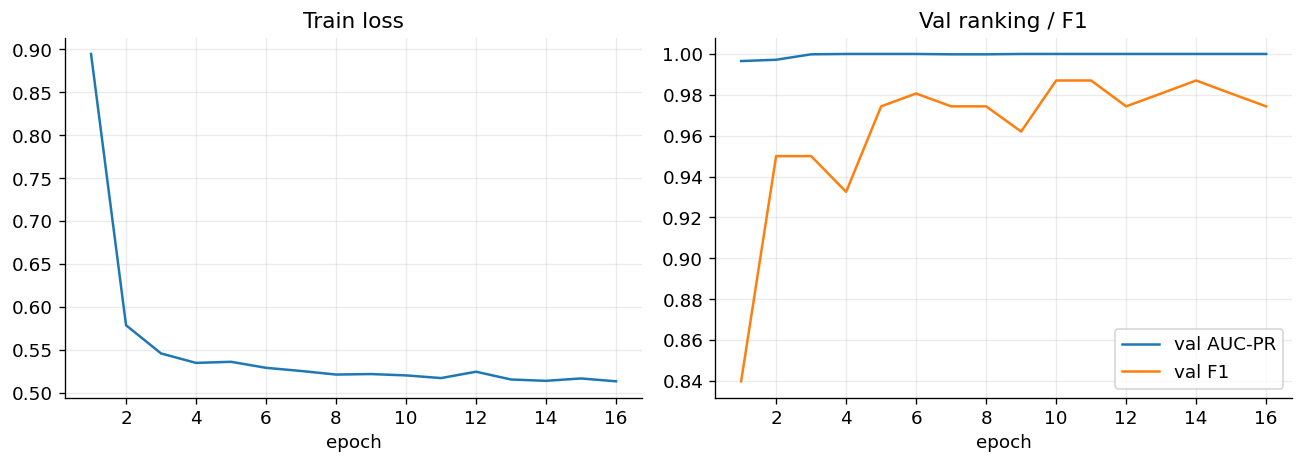

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\plots\v6_roc_pr.png


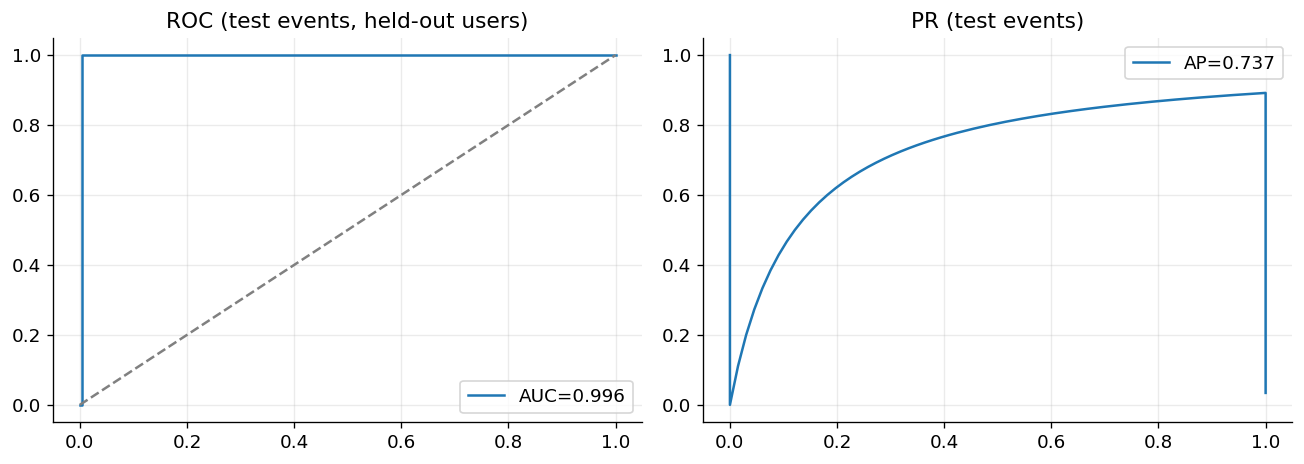

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\plots\v6_confusion_matrix.png


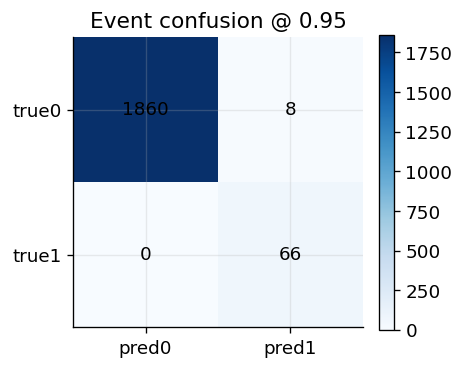

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\plots\v6_score_distribution.png


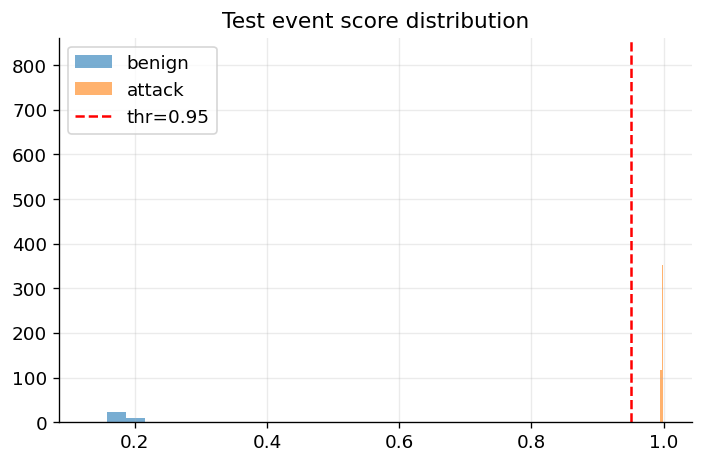

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\plots\v6_threshold_sweep.png


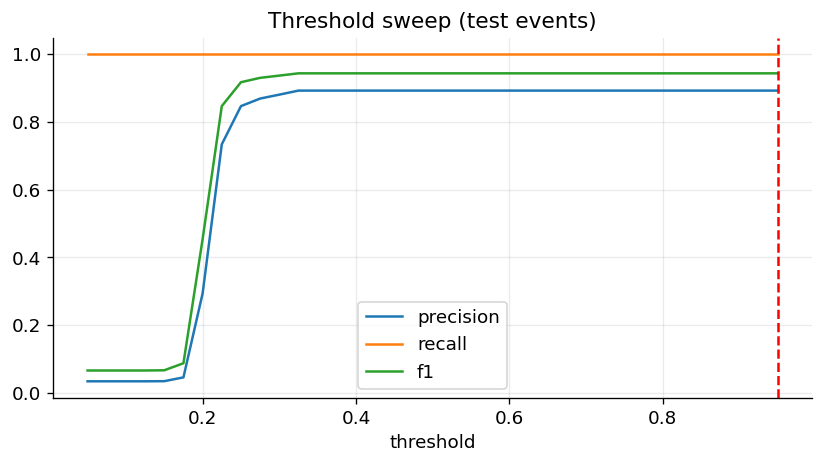

wrote C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer_v6\plots\v6_metrics_bars.png


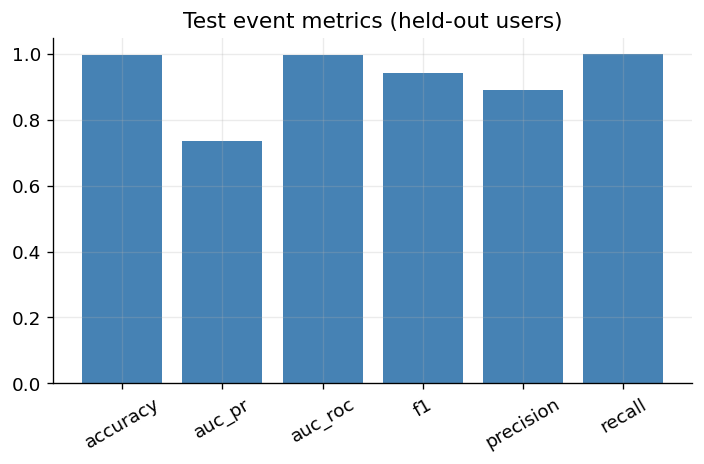

In [7]:
def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    print("wrote", path)
    plt.show()


if len(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"])
    axes[0].set_title("Train loss")
    axes[0].set_xlabel("epoch")
    axes[1].plot(history_df["epoch"], history_df["val_auc_pr"], label="val AUC-PR")
    if "select_score" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["select_score"], label="val F1")
    axes[1].set_title("Val ranking / F1")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    savefig("v6_learning_curves.png")

y_te, p_te = t6.predict(model, t6.make_loader(test_s), device)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y_te, p_te)
prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[0].plot(fpr, tpr, label=f"AUC={test_evt['auc_roc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC (test events, held-out users)")
axes[0].legend()
axes[1].plot(rec, prec, label=f"AP={test_evt['auc_pr']:.3f}")
axes[1].set_title("PR (test events)")
axes[1].legend()
savefig("v6_roc_pr.png")

cm = confusion_matrix(y_te, (p_te >= event_thr).astype(int))
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["pred0", "pred1"])
ax.set_yticklabels(["true0", "true1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
ax.set_title(f"Event confusion @ {event_thr:.2f}")
fig.colorbar(im, ax=ax, fraction=0.046)
savefig("v6_confusion_matrix.png")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(p_te[y_te == 0], bins=30, alpha=0.6, label="benign", density=True)
ax.hist(p_te[y_te == 1], bins=30, alpha=0.6, label="attack", density=True)
ax.axvline(event_thr, color="red", linestyle="--", label=f"thr={event_thr:.2f}")
ax.set_title("Test event score distribution")
ax.legend()
savefig("v6_score_distribution.png")

ths = np.linspace(0.05, 0.95, 37)
precs, recs, f1s = [], [], []
for t in ths:
    precs.append(precision_score(y_te, (p_te >= t).astype(int), zero_division=0))
    recs.append(recall_score(y_te, (p_te >= t).astype(int), zero_division=0))
    f1s.append(f1_score(y_te, (p_te >= t).astype(int), zero_division=0))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ths, precs, label="precision")
ax.plot(ths, recs, label="recall")
ax.plot(ths, f1s, label="f1")
ax.axvline(event_thr, color="red", linestyle="--")
ax.set_xlabel("threshold")
ax.set_title("Threshold sweep (test events)")
ax.legend()
savefig("v6_threshold_sweep.png")

fig, ax = plt.subplots(figsize=(6, 4))
keys = ["accuracy", "auc_pr", "auc_roc", "f1", "precision", "recall"]
ax.bar(keys, [test_evt[k] for k in keys], color="steelblue")
ax.set_ylim(0, 1.05)
ax.set_title("Test event metrics (held-out users)")
plt.xticks(rotation=30)
savefig("v6_metrics_bars.png")


## 9. Fusion handoff

`P_seq` columns for joining with `P_graph`: `username`, `window_start`, `window_end`, `P_seq`. v5 prod stack is unchanged until explicitly switched to v6 weights.


In [8]:
print(pseq.head(8).to_string(index=False))
print("\nP_seq rows:", len(pseq), "file:", OUT / "P_seq.csv")
print("v6 ckpt:", ckpt_path.exists())


            username              window_start                window_end  window_label  raw_len    P_seq  pred                   top_event_name_idx
AWSServiceRoleForEC2 2024-03-24T06:52:00+00:00 2024-03-24T07:02:00+00:00             0        7 0.186398     0          [[23, 4], [20, 2], [27, 1]]
AWSServiceRoleForEC2 2024-03-24T06:54:00+00:00 2024-03-24T07:04:00+00:00             0        7 0.186398     0          [[23, 4], [20, 2], [27, 1]]
AWSServiceRoleForEC2 2024-03-24T06:56:00+00:00 2024-03-24T07:06:00+00:00             0        7 0.186398     0          [[23, 4], [20, 2], [27, 1]]
AWSServiceRoleForEC2 2024-03-24T06:58:00+00:00 2024-03-24T07:08:00+00:00             0        7 0.186398     0          [[23, 4], [20, 2], [27, 1]]
AWSServiceRoleForEC2 2024-03-24T07:00:00+00:00 2024-03-24T07:10:00+00:00             0        7 0.186398     0          [[23, 4], [20, 2], [27, 1]]
AWSServiceRoleForEC2 2024-04-11T06:52:00+00:00 2024-04-11T07:02:00+00:00             0        8 0.206785     0 [